**Final Project Statistical Learning**
---
*Spring 2025*

**Data**

We are going to use the PDB files (available here: https://www.rcsb.org/downloads) from Ubiquitin proteins smaller than 600 residues.

**Creating Dataset**

Using DSSP we are going to extract the secondary structure of each amino acid for every sequence. To address memomry constraints, we chose only sequences shorter than 600 amino acid length.

**Pre-processing**
First, we tokenize both, the sequences (using the traditional 20 amino acids) and the secondary structures. Secondly, we pad all sequences to 600, adding zeros if it is shorter than 600. For the target data, we do one-hot encoding to represent the probability vector.

**Model**

We used BiLSTM, because as showed later it had a much better accuracy learning the patterns. Our best model had 64 in our embedding dimensions and 128 in the hidden dimension.


**Training**

Our training parameters were:
* epochs = 50
* batch_size = 16


**Testing**

Our final accuracy was 88%.
---

In [3]:
!pip install biopython
!sudo apt-get install dssp


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 47.2 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libcifpp-data libcifpp2
The following NEW packages will be installed:
  dssp libcifpp-data libcifpp2
0 upgraded, 3 newly installed, 0 to remove and 34 not upgraded.
Need to get 1,967 kB of archives.
After this operation, 15.0 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libcifpp-data all 2.0.5-1build1 [437 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libcifpp2 amd64 2.0.5-1build1 [1,019 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 dssp amd64 4.0.4-1 [511 kB]
Fetched 1,967 kB in 1s (1,341 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/Fro

In [32]:
from Bio.PDB import PDBParser, DSSP
from Bio.PDB.Polypeptide import is_aa
import glob
import numpy as np
import csv
import os
import json

import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, TimeDistributed, Bidirectional
import tensorflow.keras.backend as K

import matplotlib.pyplot as plt


In [23]:
# First we upload all the .pdb files we have available
# For demostration we upload with the code a single .pdb file
pdb_ids = glob.glob("/content/*.pdb")
pdb_ids = [id.split('.')[0] for id in pdb_ids]

# Get paths
pdb_paths = [f"{id}.pdb" for id in pdb_ids]


In [24]:
print(pdb_ids,pdb_paths)

['/content/5wvo', '/content/5wfi'] ['/content/5wvo.pdb', '/content/5wfi.pdb']


In [33]:
def get_secondary_structure(pdb_path, id):
  parser = PDBParser(QUIET=True)
  structure = parser.get_structure(id , pdb_path)
  model = structure[0]  # DSSP works on a single model

  # Run DSSP
  dssp = DSSP(model, pdb_path)

  # Get secondary structure information and reconstruct structure
  sequence = ""
  sec_struct = ""

  for key in dssp.keys():
      residue_info = dssp[key]
      aa = residue_info[1]  # One-letter amino acid
      ss = residue_info[2]  # Secondary structure code (H, B, -, )
      sequence += aa
      sec_struct += ss if ss != ' ' else '-'  # Replace blanks with '-'
  return sequence, sec_struct


# Tokenize the text to get the vocab count
def get_tokenized_seq(seq, tokenizer):
    return [tokenizer.get(aa, tokenizer['X']) for aa in seq]


def masked_categorical_crossentropy(y_true, y_pred):

    # Mask: 1 for non-padding positions, 0 for padding
    mask = tf.reduce_any(tf.not_equal(y_true, 0), axis=-1)
    mask = tf.cast(mask, dtype=tf.float32)

    # Compute loss for each step
    loss = tf.keras.losses.categorical_crossentropy(y_true, y_pred)

    # Apply mask
    loss *= mask

    # Return mean loss over unmasked elements
    return tf.reduce_sum(loss) / tf.reduce_sum(mask)

In [28]:
# Create dataset
seqs = [] #to store all the sequences
ss = [] # to store all the secondary structures

for id, path in zip(pdb_ids, pdb_paths):
  if not os.path.exists(path):
    print(f"File not found: {path}")
    continue
  seq, s = get_secondary_structure(path, id)
  seqs.append(seq)
  ss.append(s)
  if len(seqs) % 50 == 0: # Every 50 pdbs it will save the data, in case it crashes
    with open("/content/seqs_ss.tsv", "w", newline="") as f:
        writer = csv.writer(f, delimiter="\t")
        for i in range(len(seqs)):
            writer.writerow([seqs[i], ss[i]])

# To save the final dataset
with open("/content/seqs_ss.tsv", "w", newline="") as f:
        writer = csv.writer(f, delimiter="\t")
        for i in range(len(seqs)):
            writer.writerow([seqs[i], ss[i]])



In [36]:
# Load data
seqs = []
ss = []
with open("/content/seqs_ss.tsv", "r") as f:
    reader = csv.reader(f, delimiter="\t")
    for row in reader:
        seqs.append(row[0])
        ss.append(row[1])

In [37]:
# Get tokenizers: dictionary that transform a letter into a unique int
amino_acids = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M',
               'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']
aa_tokenizer = {aa: i + 1 for i, aa in enumerate(amino_acids)}  # reserve 0 for padding if needed
aa_tokenizer['X'] = len(aa_tokenizer) + 1  # for unknown

# Reverse dict
int_to_aa = {i: aa for aa, i in aa_tokenizer.items()}

seq = "ACDEF"
sec='HHEEB'
seq_token =get_tokenized_seq(seq, aa_tokenizer)
print(f'Sequence------------{seq}')
print(f'Tokenized sequence--{seq_token}' )

# Secondary Structure sequence
secondary_structures = [
    'B',  # β-bridge (isolated β-bridge residue)
    '-',  # Coil (random coil, unstructured)
    'E',  # β-strand (extended sheet conformation)
    'G',  # 3₁₀-helix (3-turn helix, tighter than α-helix)
    'H',  # α-helix (standard right-handed helix)
    'I',  # π-helix (wider than α-helix, rare)
    'S',  # Bend (sharp bend in the backbone)
    'T'   # Turn (reverse-turn, often hydrogen-bonded)
]
ss_tokenizer = {ss: i + 1 for i, ss in enumerate(secondary_structures)}
ss_tokenizer['X'] = len(ss_tokenizer) + 1  # for unknown

int_to_label = {i: label for label, i in ss_tokenizer.items()}
int_to_label[0] = 'PAD'  # Explicit padding label
structure = "HHHCCCCEEECCCHHH"
#print(get_tokenized_seq(structure, ss_tokenizer))
sec_token = get_tokenized_seq(sec, ss_tokenizer)
print(f'Secondary structure-{sec}' )
print(f'Tokenized ss--------{sec_token}' )

print(f"Padding to 7--------{pad_sequences([seq_token], maxlen=7, padding='post')}")
print(f"One-hot-------------\n{to_categorical(pad_sequences([sec_token], maxlen=7, padding='post'), num_classes=10)}")



Sequence------------ACDEF
Tokenized sequence--[1, 2, 3, 4, 5]
Secondary structure-HHEEB
Tokenized ss--------[5, 5, 3, 3, 1]
Padding to 7--------[[1 2 3 4 5 0 0]]
One-hot-------------
[[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
  [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
  [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
  [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]]


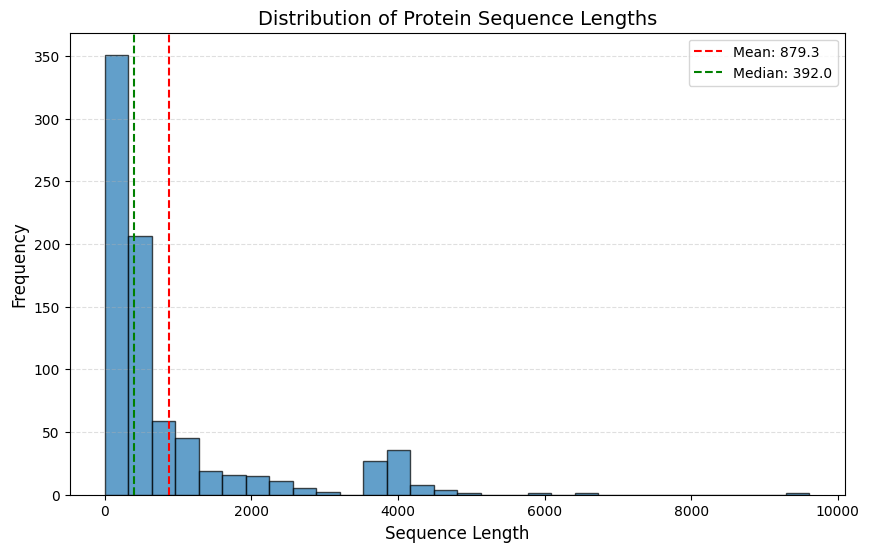

In [38]:
sequence_lengths = [len(seq) for seq in seqs]

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(sequence_lengths, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Sequence Length', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Protein Sequence Lengths', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Add mean/median annotations
mean_len = np.mean(sequence_lengths)
median_len = np.median(sequence_lengths)
plt.axvline(mean_len, color='red', linestyle='--', label=f'Mean: {mean_len:.1f}')
plt.axvline(median_len, color='green', linestyle='--', label=f'Median: {median_len:.1f}')
plt.legend()

plt.show()

547


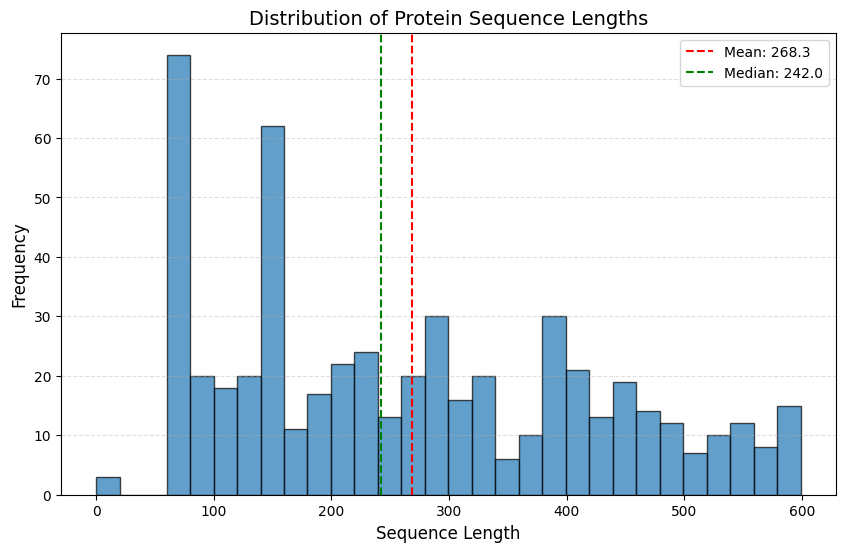

In [39]:
to_drop = []
for i,seq in enumerate((seqs)):
  if len(seq) > 600:
    to_drop.append(i)

seqs = [seqs[i] for i in range(len(seqs)) if i not in to_drop]
ss = [ss[i] for i in range(len(ss)) if i not in to_drop]

sequence_lengths = [len(seq) for seq in seqs]

print(len(seqs))
# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(sequence_lengths, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Sequence Length', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Protein Sequence Lengths', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Add mean/median annotations
mean_len = np.mean(sequence_lengths)
median_len = np.median(sequence_lengths)
plt.axvline(mean_len, color='red', linestyle='--', label=f'Mean: {mean_len:.1f}')
plt.axvline(median_len, color='green', linestyle='--', label=f'Median: {median_len:.1f}')
plt.legend()

plt.show()


In [40]:
# Building dataset
train_size = int(0.8 * len(seqs))

# Convert aminoacid sequences to integer sequences
max_input_len = 600 # set before
output_dim = len(ss_tokenizer)+1 # +padding
input_seq_train = [get_tokenized_seq(seq, aa_tokenizer) for seq in seqs[:train_size]]
target_seq_train = [get_tokenized_seq(ss, ss_tokenizer) for ss in ss[:train_size]]

input_seq_test = [get_tokenized_seq(seq, aa_tokenizer) for seq in seqs[train_size:]]
target_seq_test = [get_tokenized_seq(ss, ss_tokenizer) for ss in ss[train_size:]]



encoder_input_data_train = pad_sequences(input_seq_train,  maxlen=max_input_len, padding='post')
encoder_input_data_test = pad_sequences(input_seq_test, maxlen=max_input_len, padding='post')

encoder_target_data_train = to_categorical(pad_sequences(target_seq_train, maxlen=max_input_len, padding='post'), num_classes=output_dim)
encoder_target_data_test = to_categorical(pad_sequences(target_seq_test, maxlen=max_input_len, padding='post'), num_classes=output_dim)

print(encoder_target_data_train.shape)
print(encoder_target_data_test.shape)

(437, 600, 10)
(110, 600, 10)


In [ ]:
# Model

# Parameters
vocab_size = 22  # 20 amino acids + uncertain + padding
embedding_dim = 16
hidden_dim = 32

# Input: (batch_size, sequence_length)
inputs = Input(shape=(None,))
# Embedding layer
x = Embedding(input_dim=vocab_size, output_dim=embedding_dim, mask_zero=True)(inputs)
# BiLSTM layer
x = Bidirectional(LSTM(hidden_dim, return_sequences=True, dropout=0.3, recurrent_dropout=0.2))(x)
x = Bidirectional(LSTM(hidden_dim, return_sequences=True, dropout=0.3, recurrent_dropout=0.2))(x)
#  classification layer
outputs = (Dense(output_dim, activation='softmax'))(x)
# Model
model = Model(inputs, outputs)
model.compile(loss=masked_categorical_crossentropy, optimizer='adam', metrics=['accuracy'])
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, None, 16)  │        352 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, None)      │          0 │ input_layer_2[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, None, 64)  │     12,544 │ embedding_2[0][0… │
│ (Bidirectional)     │                   │            │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, None, 10)  │        650 │ bidirectional_2[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,546 (52.91 KB)

 Trainable params: 13,546 (52.91 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train
history = model.fit(encoder_input_data_train, encoder_target_data_train,
                    validation_data=(encoder_input_data_test, encoder_target_data_test),
                    batch_size=16,
                    epochs=10)


Epoch 1/10
 3/28 ━━━━━━━━━━━━━━━━━━━━ 1:40 4s/step - accuracy: 0.5771 - loss: 2.3002

KeyboardInterrupt: 

In [ ]:
# Save keras model
model.save('model.keras')

# Save training history
with open('training_history.json', 'w') as file:
    json.dump(history.history, file)

In [34]:
# Open model
model = tf.keras.models.load_model('/content/model_64_128.keras',
                                   custom_objects={'masked_categorical_crossentropy': masked_categorical_crossentropy})

In [41]:
loss, acc = model.evaluate(encoder_input_data_test, encoder_target_data_test)
print(f"Test Accuracy: {acc:.2f}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.8802 - loss: 1.1225
Test Accuracy: 0.88


In [42]:
predictions = model.predict(encoder_input_data_test)
predicted_classes = predictions.argmax(axis=-1)
print(predicted_classes)


4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step
[[5 5 5 ... 0 0 0]
 [5 5 5 ... 0 0 0]
 [3 9 2 ... 0 0 0]
 ...
 [2 2 2 ... 0 0 0]
 [2 2 2 ... 0 0 0]
 [3 3 3 ... 0 0 0]]


In [43]:
# Choose an example index
example_idx = 6

# Extract sequence, true secondary structure, and prediction
example_seq = seqs[train_size+example_idx]
true_ss = ss[train_size+example_idx]
predicted_ss_labels = predicted_classes[example_idx]  # From your model output

predicted_ss = [int_to_label[c] for c in predicted_ss_labels]


print("Sequence:        ", "".join(example_seq))
print("True SS:         ", "".join(true_ss))
print("Predicted SS:    ", "".join(predicted_ss))

Sequence:         SNRQEKLAQLMRQFESGGLYLRTVSDHRDEFENTFMPKLDERYWSSATFIQQGLNGKVHDPHADRTGLIISADARLGGFSTFDAATANVPSGLEPSQYFPGQFPKFDMMGAYQATWNEDIFSVDATAVSEQQMDELGIPDEYRSVFDFDRIQEKMAQPRLAGREVEPTAAKICYQPKDVLGIYVDVDSPASQSKARELQQAMREQGFDLPFIAYRGGAAQELASVMQIFVKTLTGKTITLEVESSDTIDNVKSKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLR
True SS:          --HHHHHHHHHHHHTTT-EEEEEES-HHHIIIIIIGGGT-----EEEEEE-TT--B----TTS--EEEEE-TTSEEEEEETT----PPPPTTS-HHHHTTTTS-SB-HHHHHHHH--GGGGGS-TTS--HHHHHHTT--GGGB-B-SGGGHHHHTHHHHHHT--BPPPEEEEE--GGGEEEEE--TT-HHHHHHHHHHHHHHHHTT--PPEEEEETTEEEEES---EEEEE-TTS-EEEEE--TT-BHHHHHHHHHHHH---GGGEEEEETTEEPPTTSBTGGGT--TT-EEEEEE-
Predicted SS:     -HHHHHHHHHHHHHHT--EEEEEE-----HHHEEE----------H--EEEET-T--E------T--EEEEE---TTT---EE--------T---TTE--T------HHHH--------EE-HHHHHHHHHHHHHHT---HHHHHHHHHHHHHHHHH---------T---------T-EEEEEEE---HHHHHHHHHHHHHHHHH-------E-TT---HHHH---EEEEE-TTS-EEEEE--TT-BHHHHHHHHHHHH---GGGEEEEETTEEXXTTSBTGGGT--TT-EEEEEE-PADPADPADPADPADPADPADPADPADPADPADPADPADPADPADPADPADPA

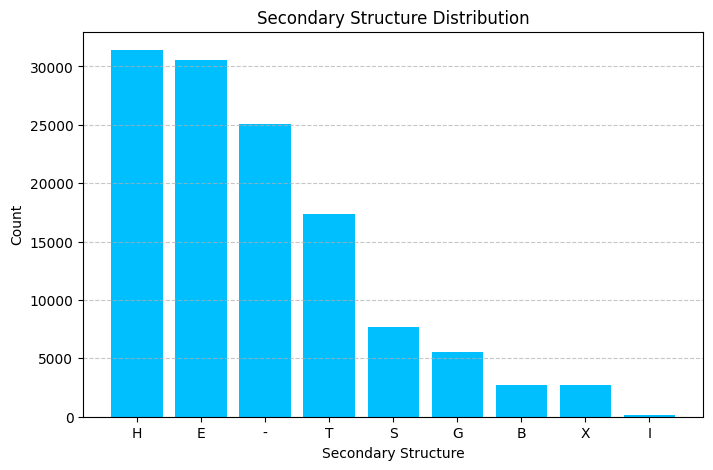

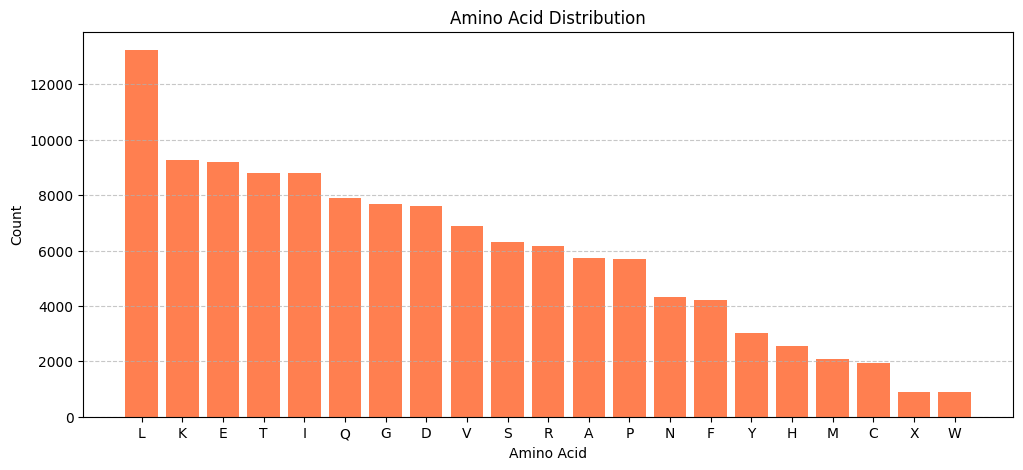

In [ ]:
# Plot the amino acid and secondary structure distribution inour training set
# For secondary structure counts
all_labels = np.concatenate(target_seq_train)

unique, counts = np.unique(all_labels, return_counts=True)
label_counts = dict(zip(unique, counts))

inv_ss_tokenizer = {v: k for k, v in ss_tokenizer.items()}

# Remove padding (0)
label_counts = {inv_ss_tokenizer[k]: v for k, v in label_counts.items() if k != 0}

# Sort by count
label_counts = dict(sorted(label_counts.items(), key=lambda item: item[1], reverse=True))

# Plot sorted secondary structure counts
plt.figure(figsize=(8, 5))
plt.bar(label_counts.keys(), label_counts.values(), color='deepskyblue')
plt.title('Secondary Structure Distribution')
plt.xlabel('Secondary Structure')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# For amino acid counts
all_aa = np.concatenate(input_seq_train)

unique_aa, counts_aa = np.unique(all_aa, return_counts=True)
aa_counts = dict(zip(unique_aa, counts_aa))

inv_aa_tokenizer = {v: k for k, v in aa_tokenizer.items()}

# Remove padding (0)
aa_counts = {inv_aa_tokenizer[k]: v for k, v in aa_counts.items() if k != 0}

# Sort by count
aa_counts = dict(sorted(aa_counts.items(), key=lambda item: item[1], reverse=True))

# Plot sorted amino acid counts
plt.figure(figsize=(12, 5))
plt.bar(aa_counts.keys(), aa_counts.values(), color='coral')
plt.title('Amino Acid Distribution')
plt.xlabel('Amino Acid')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


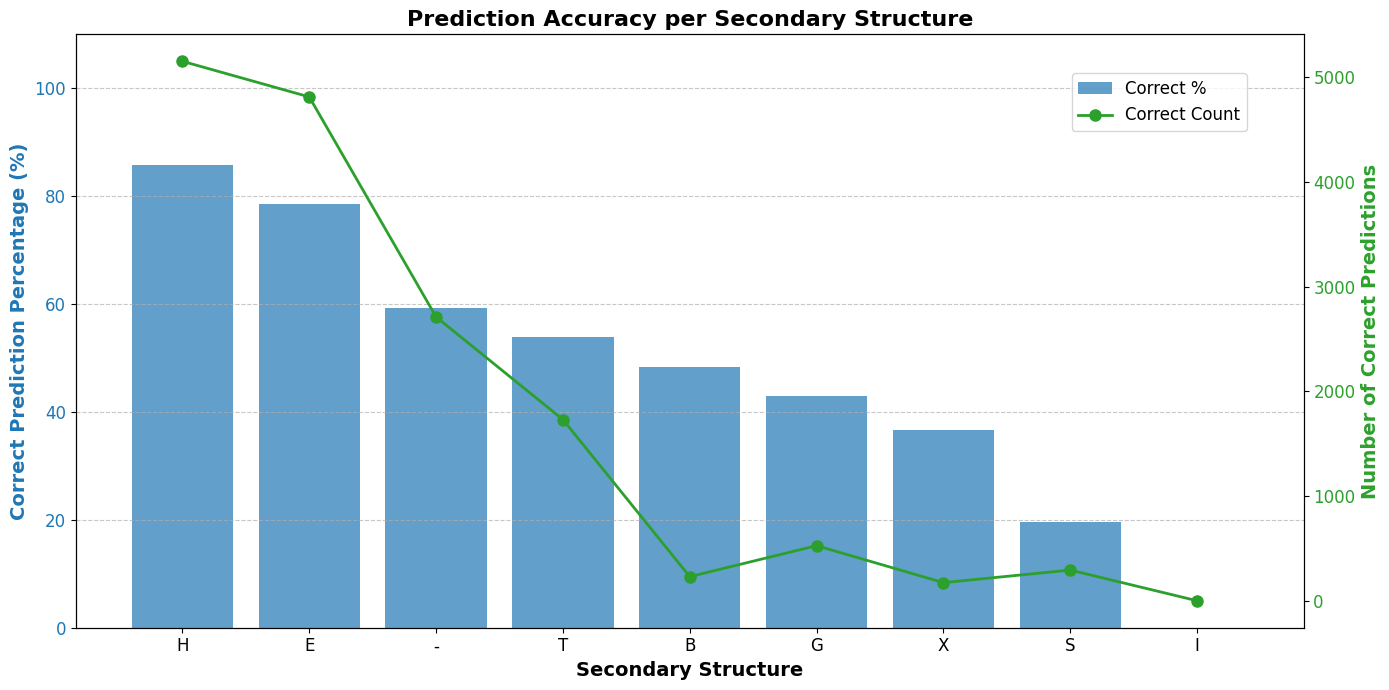

In [ ]:
# Plot percentage and absolute number of correct predictions
# Get true and predicted labels
true_classes = np.argmax(encoder_target_data_test, axis=-1)
predicted_classes = predictions.argmax(axis=-1)

inv_ss_tokenizer = {v: k for k, v in ss_tokenizer.items()}

# Count correct and total predictions
label_correct = {}
label_total = {}

for true_seq, pred_seq in zip(true_classes, predicted_classes):
    for true_label, pred_label in zip(true_seq, pred_seq):
        if true_label == 0:  # Skip padding
            continue
        ss_symbol = inv_ss_tokenizer[true_label]
        label_total[ss_symbol] = label_total.get(ss_symbol, 0) + 1
        if true_label == pred_label:
            label_correct[ss_symbol] = label_correct.get(ss_symbol, 0) + 1

# Calculate correct percentage and absolute numbers
labels = list(label_total.keys())
correct_pct = {label: label_correct.get(label, 0) / label_total[label] * 100 for label in labels}
correct_abs = {label: label_correct.get(label, 0) for label in labels}

# Sort by percentage descending
sorted_labels = sorted(correct_pct.keys(), key=lambda x: correct_pct[x], reverse=True)
sorted_pct = [correct_pct[label] for label in sorted_labels]
sorted_abs = [correct_abs[label] for label in sorted_labels]

# Plot with two y-axes
fig, ax1 = plt.subplots(figsize=(14, 7))

color_pct = 'tab:blue'
color_abs = 'tab:green'

# Bar plot for percentage
bars = ax1.bar(sorted_labels, sorted_pct, color=color_pct, alpha=0.7, label='Correct %')
ax1.set_ylabel('Correct Prediction Percentage (%)', color=color_pct, fontsize=14, weight='bold')
ax1.set_ylim(0, 110)
ax1.tick_params(axis='y', labelcolor=color_pct, labelsize=12)
ax1.tick_params(axis='x', labelsize=12)
ax1.set_xlabel('Secondary Structure', fontsize=14, weight='bold')
ax1.set_title('Prediction Accuracy per Secondary Structure', fontsize=16, weight='bold')

# Secondary y-axis
ax2 = ax1.twinx()
ax2.plot(sorted_labels, sorted_abs, color=color_abs, marker='o', markersize=8, linewidth=2, label='Correct Count')
ax2.set_ylabel('Number of Correct Predictions', color=color_abs, fontsize=14, weight='bold')
ax2.tick_params(axis='y', labelcolor=color_abs, labelsize=12)

# Optional: grid only for primary y-axis
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add legends manually
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9), fontsize=12)

plt.tight_layout()
plt.show()


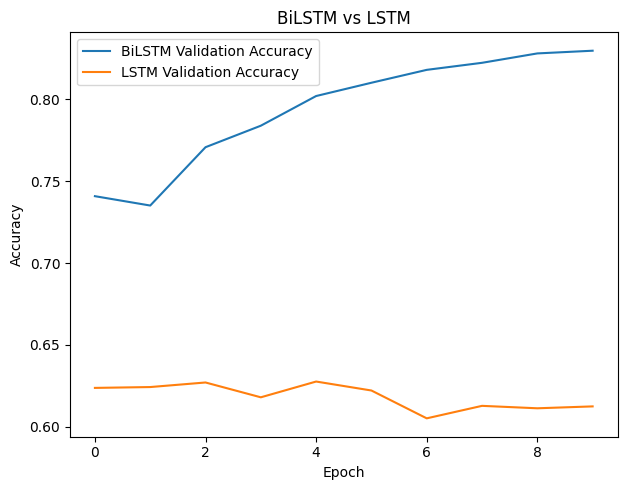

In [ ]:
# Plot accuracy of LSTM vs BiLSTM

# Load the history JSON file
with open('training_history(16,32).json', 'r') as f:
    history_bi = json.load(f)

# Convert values to lists (JSON might save them as strings)
history_bi = {k: [float(i) if isinstance(i, str) else i for i in v]
           for k, v in history_bi.items()}

# Load the history JSON file
with open('training_history_LSTM.json', 'r') as f:
    history_lstm = json.load(f)

# Convert values to lists (JSON might save them as strings)
history_lstm = {k: [float(i) if isinstance(i, str) else i for i in v]
           for k, v in history_lstm.items()}


plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history_bi['val_accuracy'], label='BiLSTM Validation Accuracy')
plt.plot(history_lstm['val_accuracy'], label='LSTM Validation Accuracy')
plt.title('BiLSTM vs LSTM')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

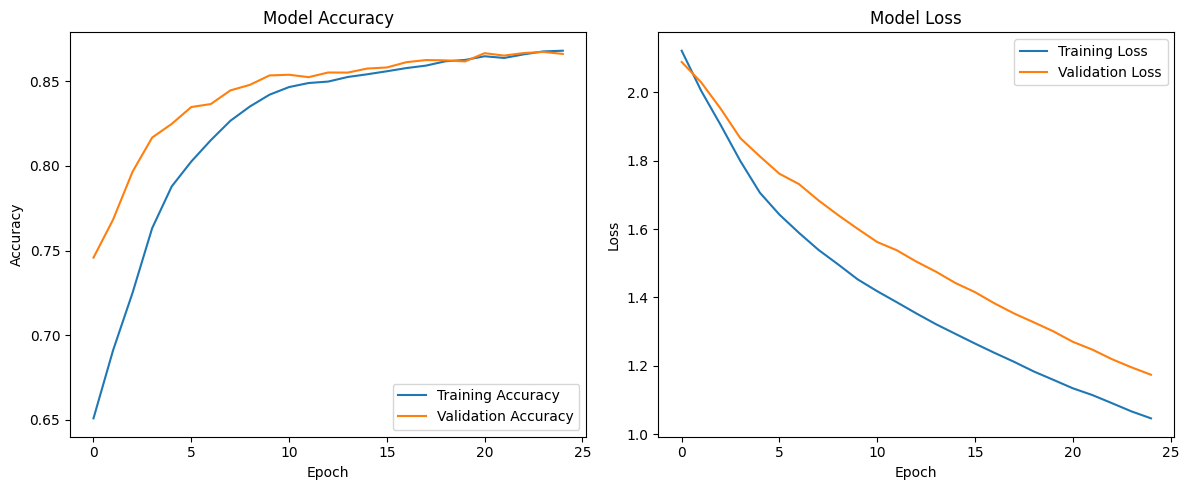

In [ ]:
# Plot best BiLSTM training accuracy
# Load the history JSON file
with open('training_history(64,128).json', 'r') as f:
    history = json.load(f)

# Convert values to lists (JSON might save them as strings)
history = {k: [float(i) if isinstance(i, str) else i for i in v]
           for k, v in history.items()}

plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss (if available)
plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()